In [21]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.colors as clr
from matplotlib import cm
from rich.progress import track

sns.set(color_codes=True, style="white")

### Load Data

In [ ]:
folder = "/Users/esumrall/Desktop/RNA-in-HOPS_condensates/FL_1x_2x/original"
os.chdir(folder)

color_FL = "#BD2433"
color_1x = "#E88791"
color_2x = "#BD2433"

In [ ]:
df_1x = pd.read_csv("colocalization_AIO_concat-FL_1x_100ms.csv")
df_2x = pd.read_csv("colocalization_AIO_concat-FL_2x_100ms.csv")

Creating enhanced raster plot with proper time alignment...


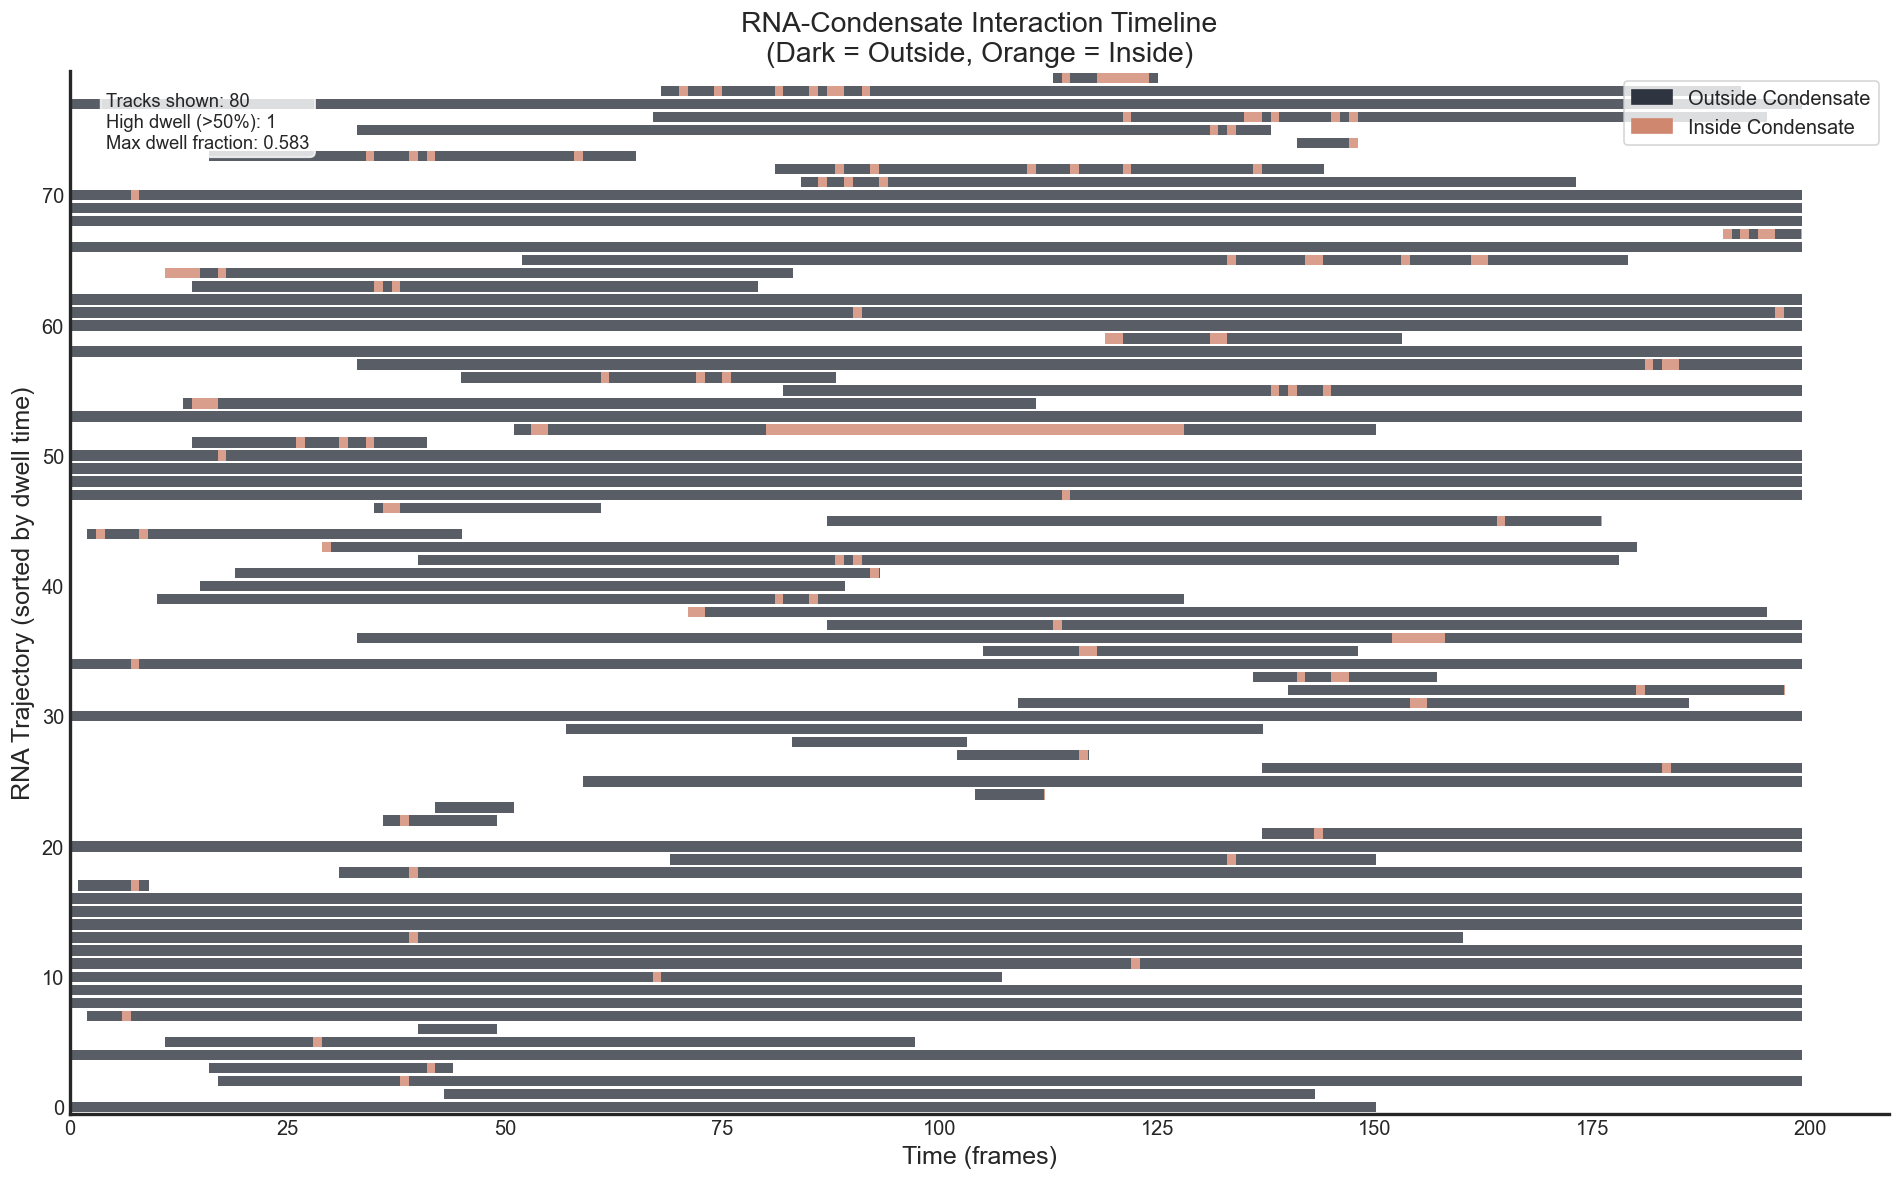

Enhanced raster plot completed!


In [24]:
# Enhanced Raster Plot - Handles Variable Track Lengths
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

print("Creating enhanced raster plot with proper time alignment...")

# Filter tracks with condensate interactions
tracks_with_condensate = df_1x.groupby('RNA_trackID')['InCondensate'].any()
valid_track_ids = tracks_with_condensate[tracks_with_condensate].index.tolist()
df_filtered = df_1x[df_1x['RNA_trackID'].isin(valid_track_ids)].copy()

# Calculate dwell statistics for sorting
track_stats = df_filtered.groupby('RNA_trackID').agg({
    'InCondensate': ['sum', 'count'],
    't': ['min', 'max']
}).round(3)

track_stats.columns = ['frames_in_condensate', 'total_frames', 'start_time', 'end_time']
track_stats['frac_dwell'] = track_stats['frames_in_condensate'] / track_stats['total_frames']
track_stats = track_stats.sort_values('frames_in_condensate')

# Select tracks for display
max_tracks = min(80, len(track_stats))  # Reduced for better visibility
selected_tracks = track_stats.head(max_tracks)

# Create figure with better dimensions
plt.figure(figsize=(16, 10), dpi=120)

# Plot each track as a horizontal line
y_positions = np.arange(max_tracks)
colors = {'outside': '#2E3440', 'inside': '#D08770'}

for i, (track_id, stats) in enumerate(selected_tracks.iterrows()):
    track_data = df_filtered[df_filtered['RNA_trackID'] == track_id].sort_values('t')
    
    # Plot continuous segments
    current_state = None
    segment_start = None
    
    for _, row in track_data.iterrows():
        time_point = row['t']
        in_condensate = row['InCondensate']
        
        # State change detection
        if current_state != in_condensate:
            # Finish previous segment
            if current_state is not None and segment_start is not None:
                color = colors['inside'] if current_state else colors['outside']
                plt.barh(i, time_point - segment_start, left=segment_start, 
                        height=0.8, color=color, edgecolor='none', alpha=0.8)
            
            # Start new segment
            current_state = in_condensate
            segment_start = time_point
    
    # Finish final segment
    if current_state is not None and segment_start is not None:
        final_time = track_data['t'].iloc[-1] + 0.1  # Add small buffer
        color = colors['inside'] if current_state else colors['outside']
        plt.barh(i, final_time - segment_start, left=segment_start, 
                height=0.8, color=color, edgecolor='none', alpha=0.8)

# Formatting
plt.xlabel('Time (frames)', fontsize=15)
plt.ylabel('RNA Trajectory (sorted by dwell time)', fontsize=15)
plt.title('RNA-Condensate Interaction Timeline\n(Dark = Outside, Orange = Inside)', fontsize=17)

# Create legend
import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(color=colors['outside'], label='Outside Condensate'),
    mpatches.Patch(color=colors['inside'], label='Inside Condensate')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add summary statistics
high_dwell_count = len(selected_tracks[selected_tracks['frac_dwell'] > 0.5])
plt.text(0.02, 0.98, 
         f'Tracks shown: {max_tracks}\nHigh dwell (>50%): {high_dwell_count}\nMax dwell fraction: {selected_tracks["frac_dwell"].max():.3f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Styling
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='both', which='major', labelsize=12, direction='in')

plt.ylim(-0.5, max_tracks - 0.5)
plt.tight_layout()
plt.savefig('raster_plot_enhanced-RNA_trajectories.png', 
            format='png', bbox_inches='tight', dpi=300)
plt.show()

print("Enhanced raster plot completed!")


Creating enhanced raster plot with proper time alignment...


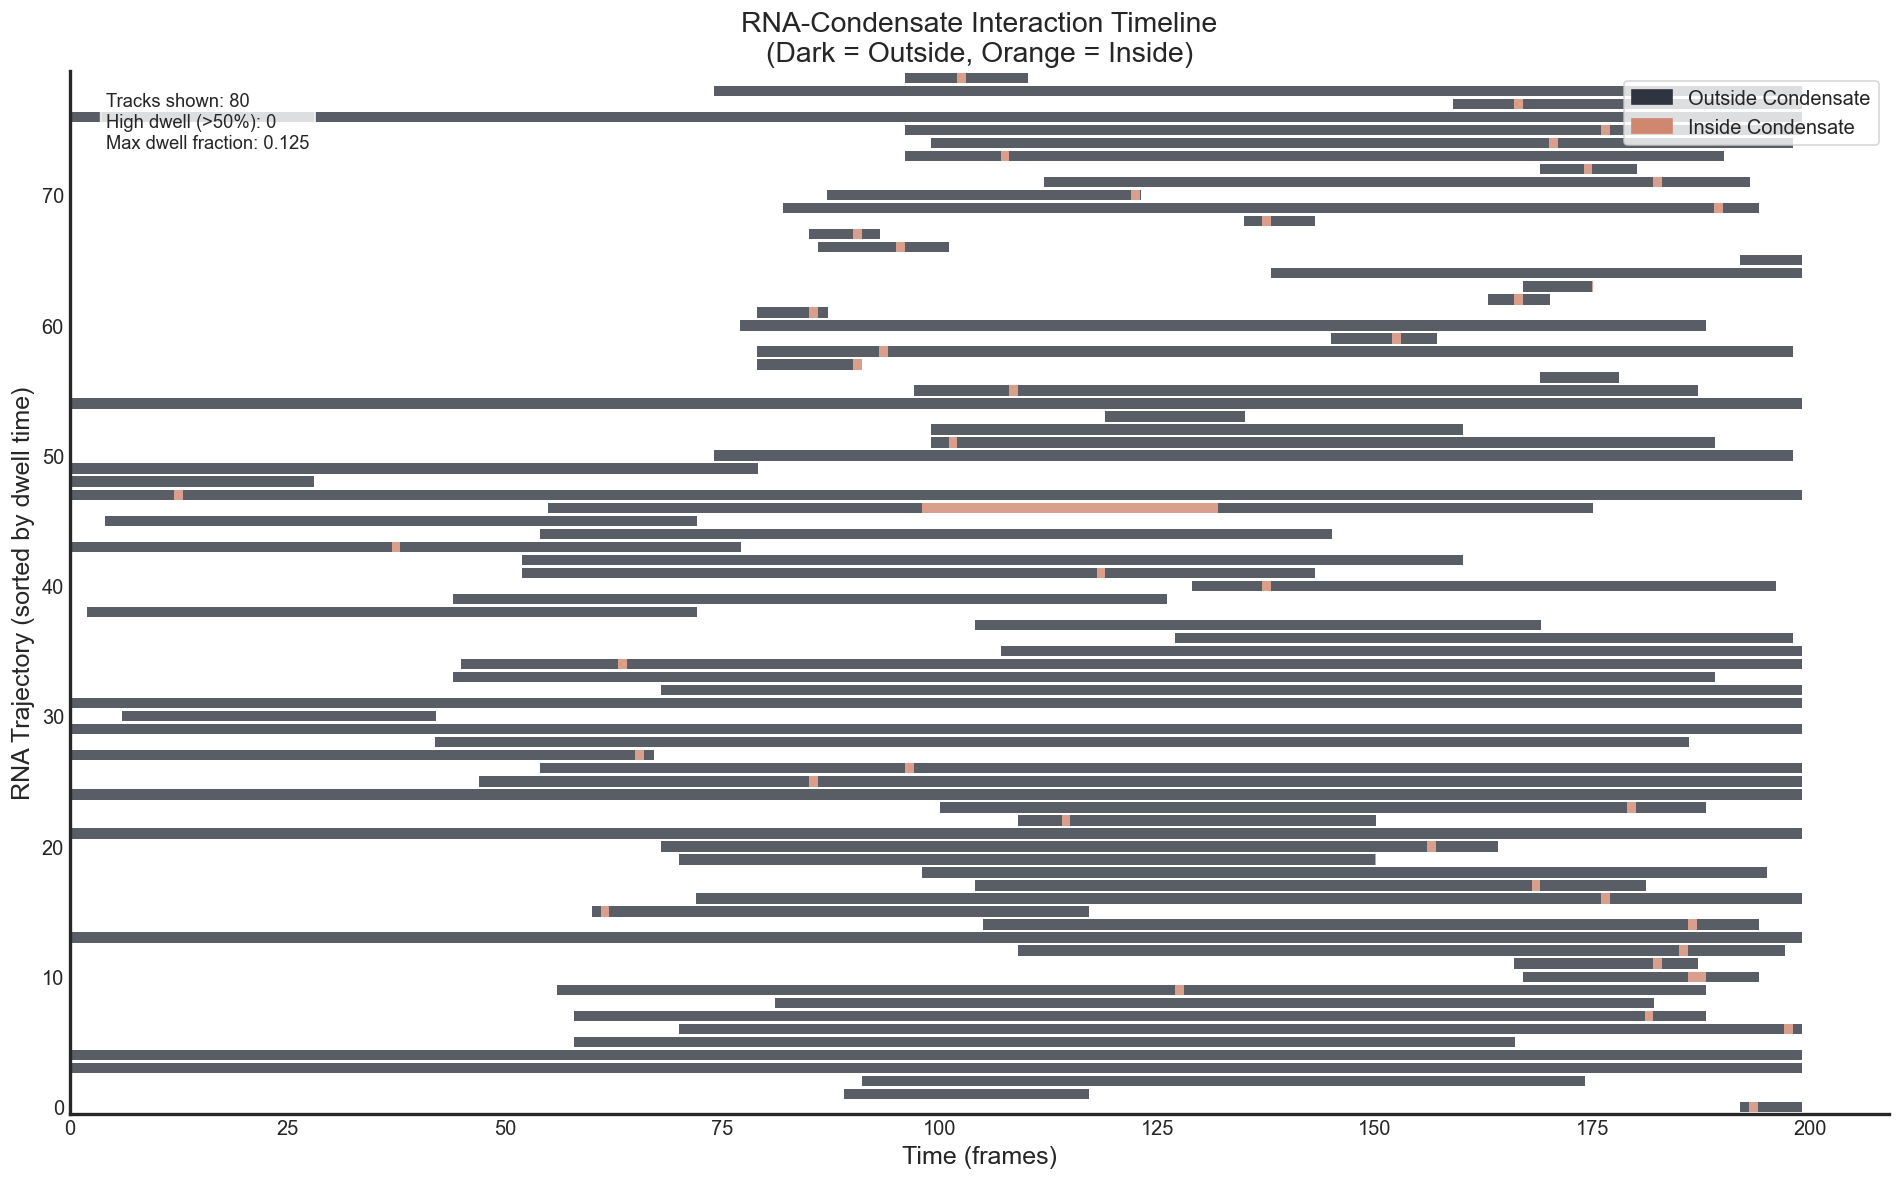

Enhanced raster plot completed!


In [25]:
# Enhanced Raster Plot - Handles Variable Track Lengths
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

print("Creating enhanced raster plot with proper time alignment...")

# Filter tracks with condensate interactions
tracks_with_condensate = df_2x.groupby('RNA_trackID')['InCondensate'].any()
valid_track_ids = tracks_with_condensate[tracks_with_condensate].index.tolist()
df_filtered = df_2x[df_2x['RNA_trackID'].isin(valid_track_ids)].copy()

# Calculate dwell statistics for sorting
track_stats = df_filtered.groupby('RNA_trackID').agg({
    'InCondensate': ['sum', 'count'],
    't': ['min', 'max']
}).round(3)

track_stats.columns = ['frames_in_condensate', 'total_frames', 'start_time', 'end_time']
track_stats['frac_dwell'] = track_stats['frames_in_condensate'] / track_stats['total_frames']
track_stats = track_stats.sort_values('frames_in_condensate')

# Select tracks for display
max_tracks = min(80, len(track_stats))  # Reduced for better visibility
selected_tracks = track_stats.head(max_tracks)

# Create figure with better dimensions
plt.figure(figsize=(16, 10), dpi=120)

# Plot each track as a horizontal line
y_positions = np.arange(max_tracks)
colors = {'outside': '#2E3440', 'inside': '#D08770'}

for i, (track_id, stats) in enumerate(selected_tracks.iterrows()):
    track_data = df_filtered[df_filtered['RNA_trackID'] == track_id].sort_values('t')
    
    # Plot continuous segments
    current_state = None
    segment_start = None
    
    for _, row in track_data.iterrows():
        time_point = row['t']
        in_condensate = row['InCondensate']
        
        # State change detection
        if current_state != in_condensate:
            # Finish previous segment
            if current_state is not None and segment_start is not None:
                color = colors['inside'] if current_state else colors['outside']
                plt.barh(i, time_point - segment_start, left=segment_start, 
                        height=0.8, color=color, edgecolor='none', alpha=0.8)
            
            # Start new segment
            current_state = in_condensate
            segment_start = time_point
    
    # Finish final segment
    if current_state is not None and segment_start is not None:
        final_time = track_data['t'].iloc[-1] + 0.1  # Add small buffer
        color = colors['inside'] if current_state else colors['outside']
        plt.barh(i, final_time - segment_start, left=segment_start, 
                height=0.8, color=color, edgecolor='none', alpha=0.8)

# Formatting
plt.xlabel('Time (frames)', fontsize=15)
plt.ylabel('RNA Trajectory (sorted by dwell time)', fontsize=15)
plt.title('RNA-Condensate Interaction Timeline\n(Dark = Outside, Orange = Inside)', fontsize=17)

# Create legend
import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(color=colors['outside'], label='Outside Condensate'),
    mpatches.Patch(color=colors['inside'], label='Inside Condensate')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Add summary statistics
high_dwell_count = len(selected_tracks[selected_tracks['frac_dwell'] > 0.5])
plt.text(0.02, 0.98, 
         f'Tracks shown: {max_tracks}\nHigh dwell (>50%): {high_dwell_count}\nMax dwell fraction: {selected_tracks["frac_dwell"].max():.3f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Styling
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='both', which='major', labelsize=12, direction='in')

plt.ylim(-0.5, max_tracks - 0.5)
plt.tight_layout()
plt.savefig('raster_plot_enhanced-RNA_trajectories.png', 
            format='png', bbox_inches='tight', dpi=300)
plt.show()

print("Enhanced raster plot completed!")


### Functions

In [26]:
def calculate_dwell_stats(df):
    array_in_condensate = df["InCondensate"].to_numpy()
    array_trackID = df["RNA_trackID"].to_numpy()
    # Find the indices where the array changes from False to True or vice versa
    change_indices_condensate = (
        np.where(array_in_condensate[:-1] != array_in_condensate[1:])[0] + 1
    )
    # Find the indices where the trackID changes
    change_indices_trackID = np.where(array_trackID[:-1] != array_trackID[1:])[0] + 1
    
    # Updated columns list with frames_in_condensate
    columns = [
        "filename",
        "fname_RNA",
        "fname_condensate",
        "rna_trackID",
        "tracklength",
        "mean_x",
        "mean_y",
        "N_dwell_per_track",
        "frames_in_condensate",        # NEW COLUMN
        "total_dwell_time_s",
        "frac_dwell",                  # Now dimensionless
        "mean_R_nm",
        "mean_d2center_nm",
        "norm_d2center",
        "mean_d2edge_nm",
        "norm_d2edge",
        "t",
        "x",
        "y",
        "InCondensate",
    ]
    
    lst_rows_of_df = []
    for i in track(range(len(change_indices_trackID) - 1)):
        idx_track_start = change_indices_trackID[i]
        idx_track_end = change_indices_trackID[i + 1]

        df_track = df.iloc[idx_track_start:idx_track_end]

        bool_change_indices_condensate_within_track = (
            change_indices_condensate >= change_indices_trackID[i]
        ) & (change_indices_condensate <= change_indices_trackID[i + 1])
        N_dwell_per_track = np.sum(bool_change_indices_condensate_within_track)

        if N_dwell_per_track == 0:
            continue

        filename = df_track["filename"].unique()[0]
        fname_RNA = df_track["fname_RNA"].unique()[0]
        fname_condensate = df_track["fname_condensate"].unique()[0]
        rna_trackID = df_track["RNA_trackID"].unique()[0]
        tracklength = df_track.shape[0]
        mean_x = df_track["x"].mean()
        mean_y = df_track["y"].mean()
        
        # CORRECTED CALCULATIONS:
        frames_in_condensate = np.sum(df_track["InCondensate"].to_numpy())  # Count of frames (dimensionless)
        total_dwell_time_s = frames_in_condensate * 0.1                     # Time in seconds  
        frac_dwell = frames_in_condensate / tracklength                     # Dimensionless fraction (0 to 1)
        
        mean_R_nm = df_track["R_nm"].mean()
        mean_d2center_nm = df_track["distance_to_center_nm"].mean()
        norm_d2center = mean_d2center_nm / mean_R_nm
        mean_d2edge_nm = df_track["distance_to_edge_nm"].mean()
        norm_d2edge = mean_d2edge_nm / mean_R_nm

        new_row = [
            filename,
            fname_RNA,
            fname_condensate,
            rna_trackID,
            tracklength,
            mean_x,
            mean_y,
            N_dwell_per_track,
            frames_in_condensate,          # NEW VALUE
            total_dwell_time_s,            # Still in seconds
            frac_dwell,                    # Now dimensionless (0-1)
            mean_R_nm,
            mean_d2center_nm,
            norm_d2center,
            mean_d2edge_nm,
            norm_d2edge,
            df_track["t"].to_numpy(),
            df_track["x"].to_numpy(),
            df_track["y"].to_numpy(),
            df_track["InCondensate"].to_numpy(),
        ]
        lst_rows_of_df.append(new_row)

    df_out = pd.DataFrame.from_records(
        lst_rows_of_df,
        columns=columns,
    )

    return df_out


### Calculate dwell statistics

In [27]:
df_dwell_1x = calculate_dwell_stats(df_1x)
df_dwell_2x = calculate_dwell_stats(df_2x)

Output()

Output()

In [28]:
df_dwell_1x.to_csv("dwell_stats_FL_1x.csv", index=False)
df_dwell_2x.to_csv("dwell_stats_FL_2x.csv", index=False)

### Plot dwell stats relationship

KDE Plot Boundary Analysis:
frac_dwell statistics:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.2651
  95th percentile: 1.0000
  99th percentile: 1.0000

norm_d2edge statistics:
  Min: 0.0019
  Max: 0.7835
  Mean: 0.3409
  95th percentile: 0.6595
  99th percentile: 0.7600

Data coverage analysis:
  Total tracks with condensate interaction: 464
  Tracks with frac_dwell > 0.5: 125
  Tracks with frac_dwell = max value: 51
  Tracks with norm_d2edge > 0.8: 0

Suggested plot boundaries:
  X-axis (frac_dwell): 0 to 1.000
  Y-axis (norm_d2edge): 0.002 to 0.760



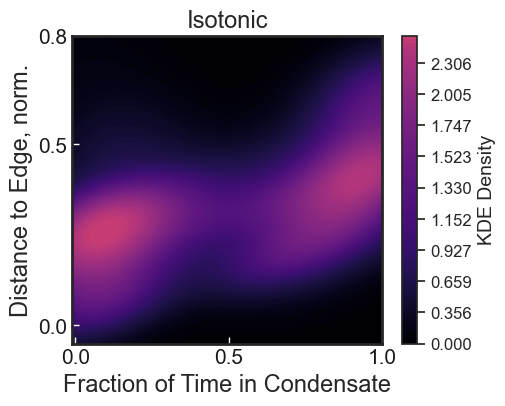

In [29]:
# Add diagnostic print statements before plotting
print("KDE Plot Boundary Analysis:")
print("=" * 40)
print(f"frac_dwell statistics:")
print(f"  Min: {df_dwell_1x['frac_dwell'].min():.4f}")
print(f"  Max: {df_dwell_1x['frac_dwell'].max():.4f}")
print(f"  Mean: {df_dwell_1x['frac_dwell'].mean():.4f}")
print(f"  95th percentile: {df_dwell_1x['frac_dwell'].quantile(0.95):.4f}")
print(f"  99th percentile: {df_dwell_1x['frac_dwell'].quantile(0.99):.4f}")
print()

print(f"norm_d2edge statistics:")
print(f"  Min: {df_dwell_1x['norm_d2edge'].min():.4f}")
print(f"  Max: {df_dwell_1x['norm_d2edge'].max():.4f}")
print(f"  Mean: {df_dwell_1x['norm_d2edge'].mean():.4f}")
print(f"  95th percentile: {df_dwell_1x['norm_d2edge'].quantile(0.95):.4f}")
print(f"  99th percentile: {df_dwell_1x['norm_d2edge'].quantile(0.99):.4f}")
print()

print(f"Data coverage analysis:")
print(f"  Total tracks with condensate interaction: {len(df_dwell_1x)}")
print(f"  Tracks with frac_dwell > 0.5: {len(df_dwell_1x[df_dwell_1x['frac_dwell'] > 0.5])}")
print(f"  Tracks with frac_dwell = max value: {len(df_dwell_1x[df_dwell_1x['frac_dwell'] == df_dwell_1x['frac_dwell'].max()])}")
print(f"  Tracks with norm_d2edge > 0.8: {len(df_dwell_1x[df_dwell_1x['norm_d2edge'] > 0.8])}")
print()

# Calculate suggested boundaries
x_max_suggested = min(df_dwell_1x['frac_dwell'].quantile(0.99), df_dwell_1x['frac_dwell'].max() * 1.1)
y_max_suggested = min(df_dwell_1x['norm_d2edge'].quantile(0.99), df_dwell_1x['norm_d2edge'].max() * 1.1)
print(f"Suggested plot boundaries:")
print(f"  X-axis (frac_dwell): 0 to {x_max_suggested:.3f}")
print(f"  Y-axis (norm_d2edge): {df_dwell_1x['norm_d2edge'].min():.3f} to {y_max_suggested:.3f}")
print()

# COLOR NORMALIZATION PARAMETERS
COLOR_NORM_PARAMS = {
    'vmin': 0.0,      # Minimum density value for color mapping
    'vmax': 5.0,       # Maximum density value for color mapping
    'n_levels': 80,    # Number of contour levels
    'cmap': 'magma'     # Colormap to use
}

from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

# Create the KDE plot first
ax = sns.kdeplot(
    data=df_dwell_1x,
    x="frac_dwell",
    y="norm_d2edge",
    fill=True,
    thresh=0,
    levels=COLOR_NORM_PARAMS['n_levels'],
    cmap=COLOR_NORM_PARAMS['cmap'],
    zorder=0,
    cbar=False,  # We'll add our own colorbar with proper normalization
)

# Apply normalization to the contour collections
norm = Normalize(vmin=COLOR_NORM_PARAMS['vmin'], vmax=COLOR_NORM_PARAMS['vmax'])

# Get all the PathCollection objects (filled contours) from the axes
collections = [child for child in ax.get_children() 
               if hasattr(child, 'set_norm') and hasattr(child, 'set_clim')]

# Apply the normalization to each collection
for collection in collections:
    collection.set_norm(norm)
    collection.set_clim(COLOR_NORM_PARAMS['vmin'], COLOR_NORM_PARAMS['vmax'])

# Add the colorbar using one of the collections
if collections:
    cbar = plt.colorbar(collections[-1], ax=ax)
    cbar.set_label("KDE Density", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    # Format the colorbar ticks
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}'))

# Style the plot
ax.spines[:].set_linewidth(2)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=15,
    direction="in",
    bottom=True,
    left=True,
    length=5,
    width=1,
    zorder=1,
    colors="white",
    labelcolor="k",
)

plt.title("Isotonic", fontsize=17)
plt.xlabel("Fraction of Time in Condensate", fontsize=17)
plt.ylabel("Distance to Edge, norm.", fontsize=17)
plt.xlim(-0.01, 1.0)
plt.xticks([0, 0.5, 1.0])
plt.ylim(-0.05, 0.8)
plt.yticks([0, 0.5, 0.8])

plt.savefig(
    "kdeplot-dwell_d2edge-FL_1x_corrected.png",
    format="png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()


KDE Plot Boundary Analysis:
frac_dwell statistics:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.2681
  95th percentile: 1.0000
  99th percentile: 1.0000

norm_d2edge statistics:
  Min: 0.0000
  Max: 0.8343
  Mean: 0.2723
  95th percentile: 0.5943
  99th percentile: 0.7272

Data coverage analysis:
  Total tracks with condensate interaction: 10396
  Tracks with frac_dwell > 0.5: 2592
  Tracks with frac_dwell = max value: 874
  Tracks with norm_d2edge > 0.8: 9

Suggested plot boundaries:
  X-axis (frac_dwell): 0 to 1.000
  Y-axis (norm_d2edge): 0.000 to 0.727



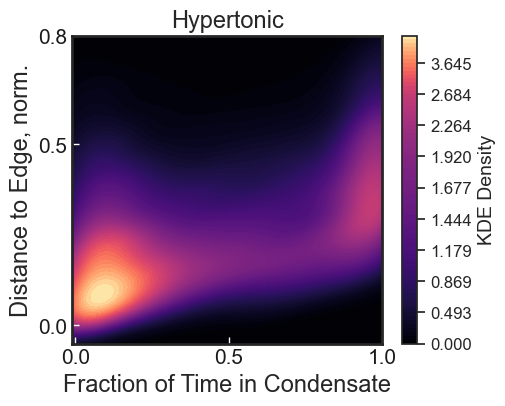

In [30]:
# Add diagnostic print statements before plotting
print("KDE Plot Boundary Analysis:")
print("=" * 40)
print(f"frac_dwell statistics:")
print(f"  Min: {df_dwell_2x['frac_dwell'].min():.4f}")
print(f"  Max: {df_dwell_2x['frac_dwell'].max():.4f}")
print(f"  Mean: {df_dwell_2x['frac_dwell'].mean():.4f}")
print(f"  95th percentile: {df_dwell_2x['frac_dwell'].quantile(0.95):.4f}")
print(f"  99th percentile: {df_dwell_2x['frac_dwell'].quantile(0.99):.4f}")
print()

print(f"norm_d2edge statistics:")
print(f"  Min: {df_dwell_2x['norm_d2edge'].min():.4f}")
print(f"  Max: {df_dwell_2x['norm_d2edge'].max():.4f}")
print(f"  Mean: {df_dwell_2x['norm_d2edge'].mean():.4f}")
print(f"  95th percentile: {df_dwell_2x['norm_d2edge'].quantile(0.95):.4f}")
print(f"  99th percentile: {df_dwell_2x['norm_d2edge'].quantile(0.99):.4f}")
print()

print(f"Data coverage analysis:")
print(f"  Total tracks with condensate interaction: {len(df_dwell_2x)}")
print(f"  Tracks with frac_dwell > 0.5: {len(df_dwell_2x[df_dwell_2x['frac_dwell'] > 0.5])}")
print(f"  Tracks with frac_dwell = max value: {len(df_dwell_2x[df_dwell_2x['frac_dwell'] == df_dwell_2x['frac_dwell'].max()])}")
print(f"  Tracks with norm_d2edge > 0.8: {len(df_dwell_2x[df_dwell_2x['norm_d2edge'] > 0.8])}")
print()

# Calculate suggested boundaries
x_max_suggested = min(df_dwell_2x['frac_dwell'].quantile(0.99), df_dwell_2x['frac_dwell'].max() * 1.1)
y_max_suggested = min(df_dwell_2x['norm_d2edge'].quantile(0.99), df_dwell_2x['norm_d2edge'].max() * 1.1)
print(f"Suggested plot boundaries:")
print(f"  X-axis (frac_dwell): 0 to {x_max_suggested:.3f}")
print(f"  Y-axis (norm_d2edge): {df_dwell_2x['norm_d2edge'].min():.3f} to {y_max_suggested:.3f}")
print()

# COLOR NORMALIZATION PARAMETERS
COLOR_NORM_PARAMS = {
    'vmin': 0.0,      # Minimum density value for color mapping
    'vmax': 5.0,       # Maximum density value for color mapping (use same as 1x for comparison)
    'n_levels': 80,    # Number of contour levels
    'cmap': 'magma'     # Colormap to use
}

from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

# Create the KDE plot first
ax = sns.kdeplot(
    data=df_dwell_2x,
    x="frac_dwell",
    y="norm_d2edge",
    fill=True,
    thresh=0,
    levels=COLOR_NORM_PARAMS['n_levels'],
    cmap=COLOR_NORM_PARAMS['cmap'],
    zorder=0,
    cbar=False,  # We'll add our own colorbar with proper normalization
)

# Apply normalization to the contour collections
norm = Normalize(vmin=COLOR_NORM_PARAMS['vmin'], vmax=COLOR_NORM_PARAMS['vmax'])

# Get all the PathCollection objects (filled contours) from the axes
collections = [child for child in ax.get_children() 
               if hasattr(child, 'set_norm') and hasattr(child, 'set_clim')]

# Apply the normalization to each collection
for collection in collections:
    collection.set_norm(norm)
    collection.set_clim(COLOR_NORM_PARAMS['vmin'], COLOR_NORM_PARAMS['vmax'])

# Add the colorbar using one of the collections
if collections:
    cbar = plt.colorbar(collections[-1], ax=ax)
    cbar.set_label("KDE Density", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    # Format the colorbar ticks
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}'))

# Style the plot
ax.spines[:].set_linewidth(2)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=15,
    direction="in",
    bottom=True,
    left=True,
    length=5,
    width=1,
    zorder=1,
    colors="white",
    labelcolor="k",
)

plt.title("Hypertonic", fontsize=17)
plt.xlabel("Fraction of Time in Condensate", fontsize=17)  # Fixed label to match the 1x version
plt.ylabel("Distance to Edge, norm.", fontsize=17)
plt.xlim(-0.01, 1.0)
plt.xticks([0, 0.5, 1.0])  # Added 0.5 tick for consistency with 1x plot
plt.ylim(-0.05, 0.8)
plt.yticks([0, 0.5, 0.8])

plt.savefig(
    "kdeplot-dwell_d2edge-FL_2x_corrected.png",  # Added "_corrected" to filename
    format="png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()


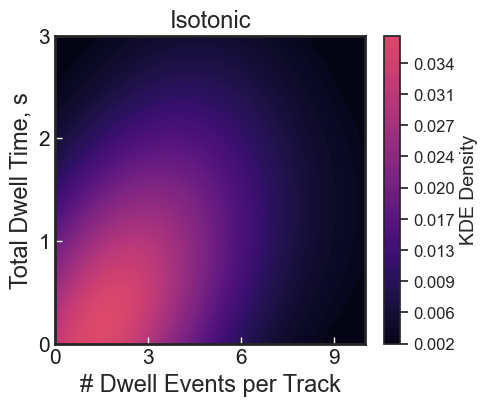

In [31]:
# COLOR NORMALIZATION PARAMETERS
COLOR_NORM_PARAMS = {
    'vmin': 0.00,      # Minimum density value for color mapping
    'vmax': 0.06,      # Maximum density value for color mapping
    'n_levels': 80,    # Number of contour levels
    'cmap': 'magma'     # Colormap to use
}

from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

# Create the KDE plot first
ax = sns.kdeplot(
    data=df_dwell_1x,
    x="N_dwell_per_track",
    y="total_dwell_time_s",
    clip=((0, 10), (0, 3)),
    fill=True,
    thresh=0,
    levels=COLOR_NORM_PARAMS['n_levels'],
    cmap=COLOR_NORM_PARAMS['cmap'],
    zorder=0,
    cbar=False,  # We'll add our own colorbar with proper normalization
)

# Apply normalization to the contour collections
norm = Normalize(vmin=COLOR_NORM_PARAMS['vmin'], vmax=COLOR_NORM_PARAMS['vmax'])

# Get all the PathCollection objects (filled contours) from the axes
collections = [child for child in ax.get_children() 
               if hasattr(child, 'set_norm') and hasattr(child, 'set_clim')]

# Apply the normalization to each collection
for collection in collections:
    collection.set_norm(norm)
    collection.set_clim(COLOR_NORM_PARAMS['vmin'], COLOR_NORM_PARAMS['vmax'])

# Add the colorbar using one of the collections
if collections:
    cbar = plt.colorbar(collections[-1], ax=ax)
    cbar.set_label("KDE Density", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    # Format the colorbar ticks
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}'))

# Style the plot
ax.spines[:].set_linewidth(2)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=15,
    direction="in",
    bottom=True,
    left=True,
    length=5,
    width=1,
    zorder=1,
    colors="white",
    labelcolor="k",
)

plt.title("Isotonic", fontsize=17)
plt.xlabel("# Dwell Events per Track", fontsize=17)
plt.ylabel("Total Dwell Time, s", fontsize=17)
plt.xticks([0, 3, 6, 9])
plt.yticks([0, 1, 2, 3])

plt.savefig(
    "kdeplot-dwellN_dwellT-FL_1x_corrected.png",  # Added "_corrected" to filename
    format="png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()


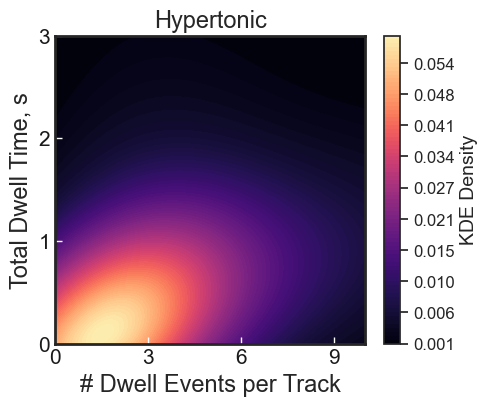

In [32]:
# COLOR NORMALIZATION PARAMETERS
COLOR_NORM_PARAMS = {
    'vmin': 0.00,      # Minimum density value for color mapping
    'vmax': 0.06,      # Maximum density value for color mapping (same as 1x for comparison)
    'n_levels': 80,    # Number of contour levels
    'cmap': 'magma'     # Colormap to use
}

from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

# Create the KDE plot first
ax = sns.kdeplot(
    data=df_dwell_2x,
    x="N_dwell_per_track",
    y="total_dwell_time_s",
    clip=((0, 10), (0, 3)),
    fill=True,
    thresh=0,
    levels=COLOR_NORM_PARAMS['n_levels'],
    cmap=COLOR_NORM_PARAMS['cmap'],
    zorder=0,
    cbar=False,  # We'll add our own colorbar with proper normalization
)

# Apply normalization to the contour collections
norm = Normalize(vmin=COLOR_NORM_PARAMS['vmin'], vmax=COLOR_NORM_PARAMS['vmax'])

# Get all the PathCollection objects (filled contours) from the axes
collections = [child for child in ax.get_children() 
               if hasattr(child, 'set_norm') and hasattr(child, 'set_clim')]

# Apply the normalization to each collection
for collection in collections:
    collection.set_norm(norm)
    collection.set_clim(COLOR_NORM_PARAMS['vmin'], COLOR_NORM_PARAMS['vmax'])

# Add the colorbar using one of the collections
if collections:
    cbar = plt.colorbar(collections[-1], ax=ax)
    cbar.set_label("KDE Density", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    # Format the colorbar ticks
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}'))

# Style the plot
ax.spines[:].set_linewidth(2)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=15,
    direction="in",
    bottom=True,
    left=True,
    length=5,
    width=1,
    zorder=1,
    colors="white",
    labelcolor="k",
)

plt.title("Hypertonic", fontsize=17)
plt.xlabel("# Dwell Events per Track", fontsize=17)
plt.ylabel("Total Dwell Time, s", fontsize=17)
plt.xticks([0, 3, 6, 9])
plt.yticks([0, 1, 2, 3])

plt.savefig(
    "kdeplot-dwellN_dwellT-FL_2x_corrected.png",  # Added "_corrected" to filename
    format="png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()


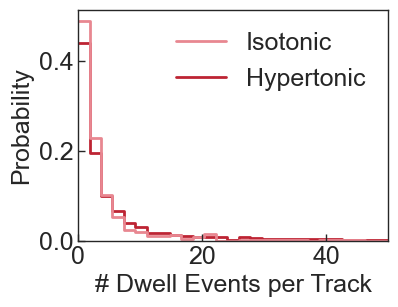

In [33]:
data = pd.concat(
    [
        pd.DataFrame(
            {
                "value": df_dwell_1x["N_dwell_per_track"].to_numpy(),
                "label": "Isotonic",
            }
        ),
        pd.DataFrame(
            {
                "value": df_dwell_2x["N_dwell_per_track"].to_numpy(),
                "label": "Hypertonic",
            }
        ),
    ],
    ignore_index=True,
)

plt.figure(figsize=(4, 3))
ax = sns.histplot(
    data=data,
    x="value",
    hue="label",
    hue_order=["Isotonic", "Hypertonic"],
    palette=[color_1x, color_2x],
    bins=27,
    binrange=(0, 50),
    stat="probability",
    common_norm=False,
    lw=2,
    element="step",
    fill=False,
)
plt.xlim(0, 50)
sns.move_legend(
    ax,
    1,
    title=None,
    frameon=False,
    fontsize=18,
)
plt.xlabel("# Dwell Events per Track", fontsize=18)
plt.ylabel("Probability", fontsize=18)
plt.gca().spines[:].set_linewidth(1)
plt.gca().tick_params(
    axis="both",
    which="major",
    labelsize=18,
    direction="in",
    bottom=True,
    left=True,
    length=5,
    width=1,
)
plt.gca().set_axisbelow(False)
plt.gca().tick_params(axis="both", which="major", labelsize=18)
plt.savefig(
    "histo-dwellN-FL_1x_vs_2x.png",
    format="png",
    bbox_inches="tight",
    dpi=300,
)

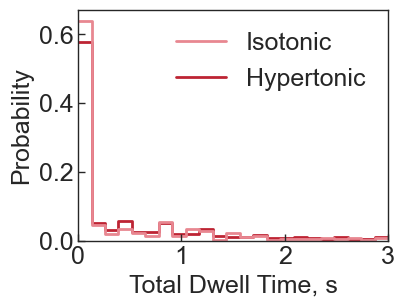

In [34]:
data = pd.concat(
    [
        pd.DataFrame(
            {
                "value": df_dwell_1x["total_dwell_time_s"].to_numpy(),
                "label": "Isotonic",
            }
        ),
        pd.DataFrame(
            {
                "value": df_dwell_2x["total_dwell_time_s"].to_numpy(),
                "label": "Hypertonic",
            }
        ),
    ],
    ignore_index=True,
)

plt.figure(figsize=(4, 3))
ax = sns.histplot(
    data=data,
    x="value",
    hue="label",
    hue_order=["Isotonic", "Hypertonic"],
    palette=[color_1x, color_2x],
    bins=23,
    binrange=(0, 3),
    stat="probability",
    common_norm=False,
    lw=2,
    element="step",
    fill=False,
)
plt.xlim(0, 3)
sns.move_legend(
    ax,
    1,
    title=None,
    frameon=False,
    fontsize=18,
)
plt.xlabel("Total Dwell Time, s", fontsize=18)
plt.ylabel("Probability", fontsize=18)
plt.gca().spines[:].set_linewidth(1)
plt.gca().tick_params(
    axis="both",
    which="major",
    labelsize=18,
    direction="in",
    bottom=True,
    left=True,
    length=5,
    width=1,
)
plt.gca().set_axisbelow(False)
plt.gca().tick_params(axis="both", which="major", labelsize=18)
plt.savefig(
    "histo-total_dwell-FL_1x_vs_2x.png",
    format="png",
    bbox_inches="tight",
    dpi=300,
)

### Pick and plot tracks

In [35]:
df_dwell_1x.keys()


Index(['filename', 'fname_RNA', 'fname_condensate', 'rna_trackID',
       'tracklength', 'mean_x', 'mean_y', 'N_dwell_per_track',
       'frames_in_condensate', 'total_dwell_time_s', 'frac_dwell', 'mean_R_nm',
       'mean_d2center_nm', 'norm_d2center', 'mean_d2edge_nm', 'norm_d2edge',
       't', 'x', 'y', 'InCondensate'],
      dtype='object')

In [36]:
df_1x_multiple_short = df_dwell_1x.sort_values(
    by=[
        "N_dwell_per_track",
        "total_dwell_time_s",
        'norm_d2edge',
    ],
    ascending=[
        False,
        False,
        True,
    ],
).iloc[:5]
df_2x_multiple_short = df_dwell_2x.sort_values(
    by=[
        "N_dwell_per_track",
        "total_dwell_time_s",
        'norm_d2edge',
    ],
    ascending=[
        False,
        False,
        True,
    ],
).iloc[:5]
df_2x_multiple_short

,filename,fname_RNA,fname_condensate,rna_trackID,tracklength,mean_x,mean_y,N_dwell_per_track,frames_in_condensate,total_dwell_time_s,frac_dwell,mean_R_nm,mean_d2center_nm,norm_d2center,mean_d2edge_nm,norm_d2edge,t,x,y,InCondensate
61,colocalization_AIO-20220508-FLmRNA_2x_FOV-1-cr...,SPT_results_AIO-20220508-FLmRNA_2x_FOV-right_r...,condensates_AIO-20220508-FLmRNA_2x_FOV-1-cropp...,322.0,200,137.660186,378.731906,116,112,11.2,0.560,569.464213,219.146946,0.384830,94.960120,0.166753,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[137.69307912386355, 137.71208607686205, 137.7...","[378.6440485257794, 378.75248794702105, 378.76...","[False, False, False, False, False, True, True..."
3646,colocalization_AIO-20220508-FLmRNA_2x_FOV-8-cr...,SPT_results_AIO-20220508-FLmRNA_2x_FOV-8-right...,condensates_AIO-20220508-FLmRNA_2x_FOV-8-cropp...,191.0,200,220.237590,370.058995,104,111,11.1,0.555,747.342476,229.556937,0.307164,167.851663,0.224598,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[218.4524354560062, 218.97204937484284, 220.72...","[370.2333396998037, 370.1793024402029, 370.002...","[True, True, True, True, True, True, False, Tr..."
6332,colocalization_AIO-20220508-FLmRNA_2x_FOV-15-c...,SPT_results_AIO-20220508-FLmRNA_2x_FOV-right_r...,condensates_AIO-20220508-FLmRNA_2x_FOV-15-crop...,19.0,200,71.499039,254.380170,104,109,10.9,0.545,235.095906,88.087174,0.374686,132.370995,0.563051,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[71.42104317129984, 71.36008667452495, 71.3132...","[254.1155824403704, 254.084181565396, 254.1058...","[True, True, False, True, False, True, False, ..."
2724,colocalization_AIO-20220508-FLmRNA_2x_FOV-6-cr...,SPT_results_AIO-20220508-FLmRNA_2x_FOV-6-right...,condensates_AIO-20220508-FLmRNA_2x_FOV-6-cropp...,9.0,200,290.860766,65.082711,102,124,12.4,0.620,245.797268,123.753735,0.503479,113.404789,0.461375,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[292.06934880688, 292.5981856903001, 292.99078...","[65.2507573026098, 64.94385643215256, 64.55890...","[False, False, False, False, True, False, Fals..."
36,colocalization_AIO-20220508-FLmRNA_2x_FOV-1-cr...,SPT_results_AIO-20220508-FLmRNA_2x_FOV-right_r...,condensates_AIO-20220508-FLmRNA_2x_FOV-1-cropp...,214.0,200,63.923584,338.707509,96,118,11.8,0.590,550.558955,318.963049,0.579344,86.739894,0.157549,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[64.0386079898245, 64.07149597314853, 64.07134...","[338.81662545571646, 338.97988411644906, 338.6...","[False, False, True, False, True, False, False..."
